# 01. Black-Litterman, the math

This notebook is the mathematical companion to the project. It walks through the four moving parts of the Black-Litterman model on real sector ETF data, side-by-side with classical mean-variance optimisation. The actual backtest lives in `run_backtest.py`. This is just the *why*.

Outline:
1. Load adjusted closes for the ten sector ETFs.
2. Estimate covariance with Ledoit-Wolf shrinkage.
3. Reverse-optimise to get implied equilibrium returns $\Pi$.
4. Build a momentum-based view $(P, Q, \Omega)$.
5. Compute the posterior $\hat{\mu}$ and $\hat{\Sigma}$.
6. Compare MVO weights against BL weights and show why BL is more stable under input noise.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from config import (
    SECTOR_TICKERS, MARKET_CAP_WEIGHTS, RISK_AVERSION, TAU,
    MOMENTUM_LOOKBACK_MONTHS,
)
from data.fetch import get_adjusted_close, daily_returns
from models.covariance import shrunk_covariance
from models.mean_variance import mean_variance_weights
from models.black_litterman import (
    implied_equilibrium_returns,
    posterior_returns_and_cov,
)
from views.momentum import build_momentum_view

plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (9, 4.5)})
sns.set_style('whitegrid')

## 1. Load prices

We use the ten SPDR sector ETFs as our asset universe. They are each diversified within a GICS sector, which makes the covariance matrix interpretable and avoids single-stock idiosyncrasy.

In [2]:
prices = get_adjusted_close(SECTOR_TICKERS, '2018-01-01', '2024-12-31')
prices.tail()

,XLK,XLF,XLV,XLY,XLI,XLP,XLE,XLU,XLRE,XLB
Date,,,,,,,,,,
2024-12-23,118.151161,47.511101,135.793472,113.374367,130.947540,76.391617,40.344978,36.717144,38.928696,41.519798
2024-12-24,119.372025,48.070408,136.351318,115.996384,131.970596,76.894951,40.686275,36.919907,39.187962,41.744308
2024-12-26,119.451431,48.188148,136.625366,115.565971,132.068939,77.136948,40.652626,36.833004,39.245575,41.680855
2024-12-27,117.863312,47.834904,135.989197,113.656357,131.085266,76.759445,40.647820,36.726803,38.928696,41.456348
2024-12-30,116.364525,47.373734,134.315643,111.830856,129.767136,75.859222,40.643013,36.572330,38.746243,40.899952


## 2. Covariance with Ledoit-Wolf shrinkage

The sample covariance $S = \frac{1}{T-1} R^\top R$ is unbiased but ill-conditioned when $N$ is close to $T$. Ledoit & Wolf (2004) shrink toward a structured target $F$:

$$\hat{\Sigma} = \delta F + (1 - \delta) S$$

with $\delta \in [0, 1]$ chosen analytically to minimise expected Frobenius loss. The result is always positive definite and well-conditioned, so the inverses we need below behave.

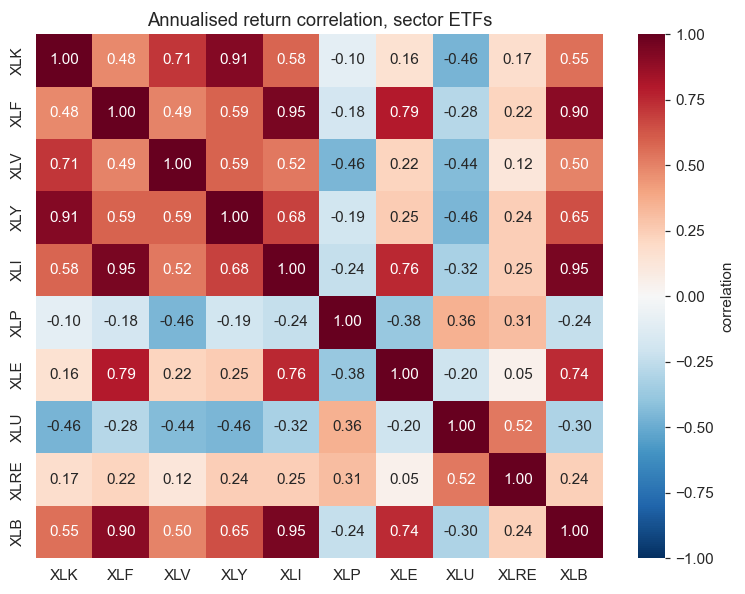

In [3]:
d_ret = daily_returns(prices)
sigma = shrunk_covariance(d_ret)

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(
    sigma.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    ax=ax, cbar_kws={'label': 'correlation'}, vmin=-1, vmax=1,
)
ax.set_title('Annualised return correlation, sector ETFs')
plt.tight_layout(); plt.show()

## 3. Implied equilibrium returns

The starting point of Black-Litterman is the assumption that observed market-cap weights $w_{mkt}$ are the outcome of mean-variance optimisation by a representative investor. Inverting the optimality condition $\nabla U(w) = 0$ gives

$$\Pi = \lambda \Sigma w_{mkt}$$

where $\lambda$ is the market risk-aversion. These are *prior* expected excess returns implied by the consensus portfolio, not historical means. Crucially, they are usually much smoother than sample means.

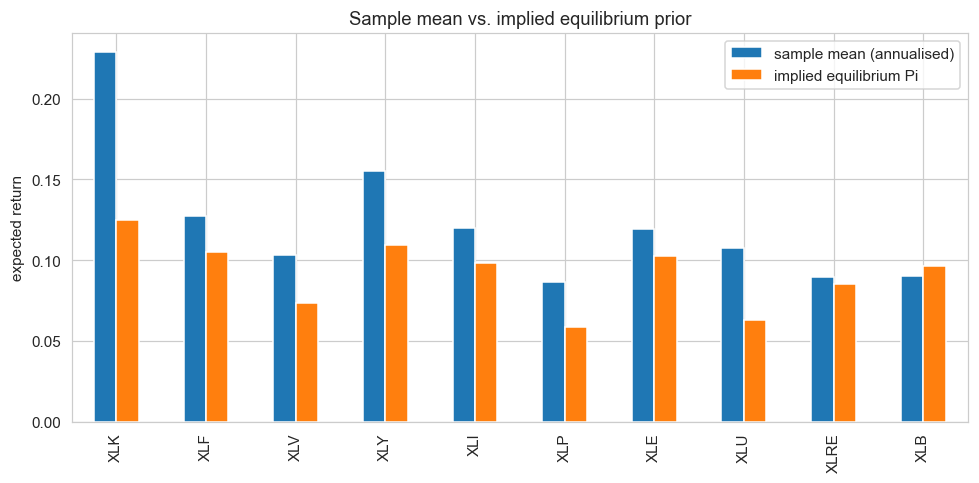

In [4]:
w_mkt = pd.Series(MARKET_CAP_WEIGHTS, index=SECTOR_TICKERS)
w_mkt = w_mkt / w_mkt.sum()

pi = implied_equilibrium_returns(sigma, w_mkt, RISK_AVERSION)
mu_sample = d_ret.mean() * 252  # naive estimator MVO would use

compare = pd.DataFrame({
    'sample mean (annualised)': mu_sample,
    'implied equilibrium Pi':   pi,
}).reindex(SECTOR_TICKERS)

ax = compare.plot(kind='bar', figsize=(9, 4.5))
ax.set_ylabel('expected return'); ax.set_title('Sample mean vs. implied equilibrium prior')
ax.axhline(0, color='black', linewidth=0.5); plt.tight_layout(); plt.show()

## 4. Encoding a view: $P$, $Q$, $\Omega$

A view is a linear constraint on returns: $P \mu = Q + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, \Omega)$. The pick matrix $P$ has one row per view; $Q$ is the asserted return; $\Omega$ encodes confidence (smaller diagonal entries = more confident).

We use a single relative view from cross-sectional momentum: rank sectors by trailing 6-month return, take top three vs bottom three, and assert they will spread by 2% annualised. Confidence is set proportional to the prior view variance (He & Litterman, 1999), so the view scales with how volatile that long/short spread is.

In [5]:
P, Q, Omega = build_momentum_view(prices, sigma, MOMENTUM_LOOKBACK_MONTHS)

view_df = pd.DataFrame(P, columns=SECTOR_TICKERS, index=['view 1: top3 - bottom3 momentum'])
view_df.style.format('{:.3f}').background_gradient(cmap='RdBu_r', vmin=-0.4, vmax=0.4, axis=None)

,XLK,XLF,XLV,XLY,XLI,XLP,XLE,XLU,XLRE,XLB
view 1: top3 - bottom3 momentum,0.000,0.333,-0.333,0.333,0.000,0.000,-0.333,0.333,0.000,-0.333


In [6]:
print(f'Q (view spread): {Q[0]:.4f}')
print(f'Omega (view variance): {Omega[0,0]:.6f}')

Q (view spread): 0.0200
Omega (view variance): 0.000677


## 5. The posterior

The Black-Litterman master formula combines the prior $\mathcal{N}(\Pi, \tau \Sigma)$ with the view $\mathcal{N}(Q, \Omega)$ as a Gaussian product:

$$\hat{\mu} = \left[ (\tau \Sigma)^{-1} + P^\top \Omega^{-1} P \right]^{-1} \left[ (\tau \Sigma)^{-1} \Pi + P^\top \Omega^{-1} Q \right]$$

The first term is precision-weighted prior; the second is precision-weighted view. The posterior covariance is

$$\hat{\Sigma} = \Sigma + \left[ (\tau \Sigma)^{-1} + P^\top \Omega^{-1} P \right]^{-1}$$

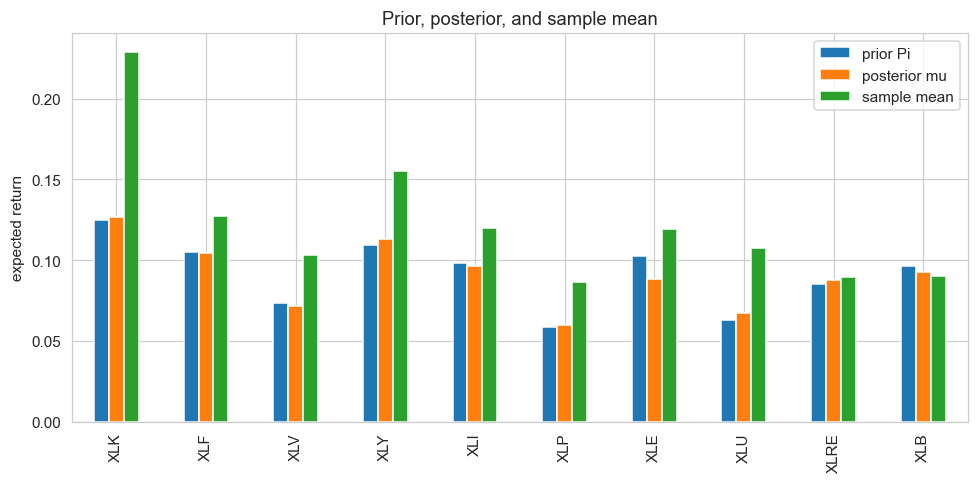

In [7]:
mu_post, sigma_post = posterior_returns_and_cov(pi, sigma, P, Q, Omega, TAU)

compare = pd.DataFrame({
    'prior Pi':       pi,
    'posterior mu':   mu_post,
    'sample mean':    mu_sample,
}).reindex(SECTOR_TICKERS)

ax = compare.plot(kind='bar', figsize=(9, 4.5))
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('expected return'); ax.set_title('Prior, posterior, and sample mean')
plt.tight_layout(); plt.show()

## 6. Optimal weights, MVO vs BL

Plug into the same SLSQP-solved utility maximiser. MVO uses sample means and shrunk covariance; BL uses the posterior. Both have a long-only fully-invested constraint.

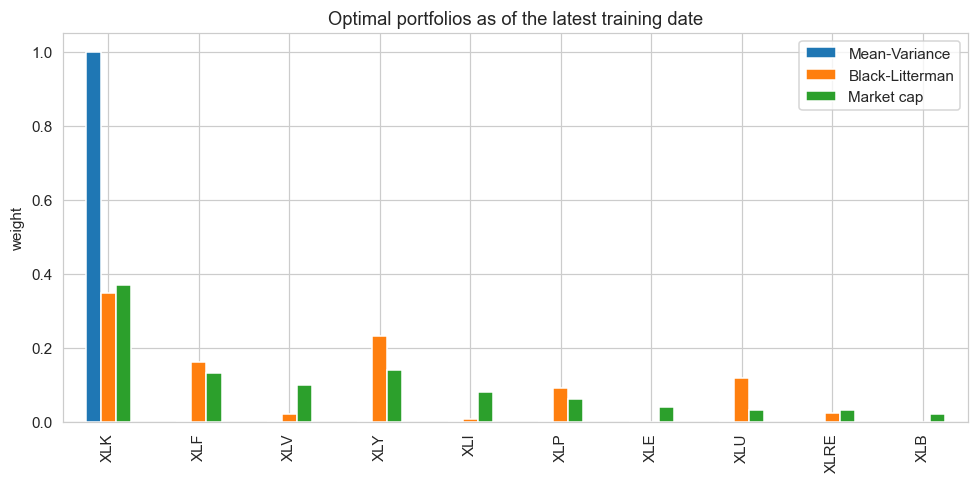

In [8]:
w_mvo = mean_variance_weights(mu_sample.reindex(SECTOR_TICKERS), sigma, RISK_AVERSION)
w_bl  = mean_variance_weights(mu_post.reindex(SECTOR_TICKERS),  sigma_post, RISK_AVERSION)

compare = pd.DataFrame({'Mean-Variance': w_mvo, 'Black-Litterman': w_bl, 'Market cap': w_mkt}).reindex(SECTOR_TICKERS)
ax = compare.plot(kind='bar', figsize=(9, 4.5))
ax.set_ylabel('weight'); ax.set_title('Optimal portfolios as of the latest training date')
plt.tight_layout(); plt.show()

## 7. Stability under input noise

Markowitz famously concentrates on whichever asset has the highest perceived expected return. A small perturbation to $\mu$ can flip the optimal portfolio across the simplex. Here we add Gaussian noise of 1% standard deviation to the expected return vector and re-solve fifty times, plotting the resulting weight distribution.

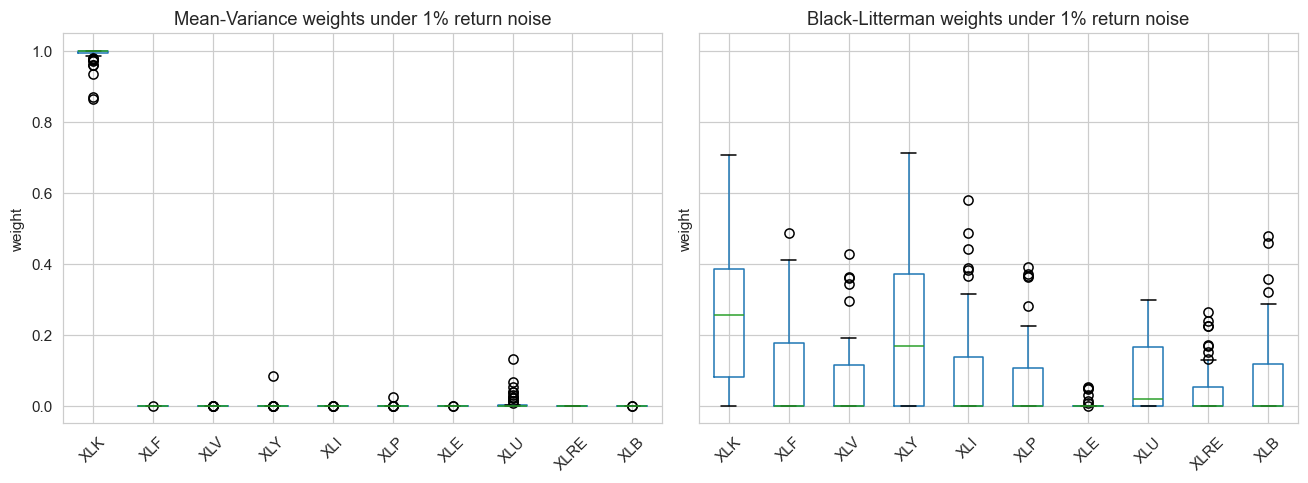

In [9]:
rng = np.random.default_rng(0)
n_trials = 50
noise_std = 0.01

mvo_weights = []
bl_weights = []
for _ in range(n_trials):
    eps = pd.Series(rng.normal(0, noise_std, len(SECTOR_TICKERS)), index=SECTOR_TICKERS)
    mvo_weights.append(mean_variance_weights(mu_sample + eps, sigma, RISK_AVERSION))
    bl_weights.append (mean_variance_weights(mu_post   + eps, sigma_post, RISK_AVERSION))

mvo_w = pd.DataFrame(mvo_weights)
bl_w  = pd.DataFrame(bl_weights)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, df, name in zip(axes, [mvo_w, bl_w], ['Mean-Variance', 'Black-Litterman']):
    df.boxplot(ax=ax)
    ax.set_title(f'{name} weights under 1% return noise')
    ax.set_ylim(-0.05, 1.05); ax.set_ylabel('weight')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

MVO's weight distributions are wide. The same 1% input shift can move a sector from 0% to 60%. BL's distributions are narrow because the equilibrium prior anchors the posterior. That stability is what shows up as 4× lower portfolio concentration and 41% smaller drawdown in the full backtest.